<a href="https://colab.research.google.com/github/martincastanonicolas-source/AI/blob/master/Ejercicios%20AI/Martin_Castano_Nicolas_U3_Practica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [29]:
# Verificar GPU en Colab
import tensorflow as tf
print("GPU disponible: ", tf.config.list_physical_devices('GPU'))

# Imports
import numpy as np
import keras
from keras import layers

# Descargar dataset
!gdown 199dxi24ln2b-_S4mhH2sgpr3nvxmoxZN -O titulares.txt

# Carga texto
with open('titulares.txt', 'r', encoding='utf-8') as f:
    text = f.read()

print(f"Caracteres totales: {len(text)}")
print(f"Muestra:\n{text[:500]}")

GPU disponible:  [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Downloading...
From: https://drive.google.com/uc?id=199dxi24ln2b-_S4mhH2sgpr3nvxmoxZN
To: /content/titulares.txt
100% 60.4k/60.4k [00:00<00:00, 72.1MB/s]
Caracteres totales: 60438
Muestra:
nueva ley de energia promete revolucionar el sector electrico
el cambio climatico sigue siendo una amenaza global
inversionistas buscan oportunidades en energias renovables
aumenta la demanda de vehiculos electricos
vacunas contra covid19 cuando estaremos todos protegidos
el debate sobre las vacunas sigue dividiendo opiniones
expertos en salud analizan la efectividad de las vacunas
vacunacion masiva contra el coronavirus en marcha
el mercado de criptomonedas se dispara a nuevas alturas
es bitcoi


In [30]:
# Crear vocabulario
vocab = sorted(set(text))
vocab_size = len(vocab)
print(f"Vocabulario: {vocab_size} caracteres únicos")

# Mapeos
char_to_idx = {ch: i for i, ch in enumerate(vocab)}
idx_to_char = {i: ch for i, ch in enumerate(vocab)}

def encode(s):
  return [char_to_idx[c] for c in s]

def decode(ids):
  return ''.join([idx_to_char[i] for i in ids])

# Test
print(encode(vocab[0]))
print(decode([27, 5, 14, 8]))

Vocabulario: 33 caracteres únicos
[0]
t4ga


In [31]:
# Parémetros
SEQ_LENGTH = 80
BATCH_SIZE = 64

# Tokenizar todo
tokens = np.array(encode(text))

def crear_secuencias(tokens, seq_len):
  X, y = [], []
  for i in range(len(tokens) - seq_len):
    X.append(tokens[i:i+seq_len])
    y.append(tokens[i+1:i+seq_len+1])
  return np.array(X), np.array(y)

X, y = crear_secuencias(tokens, SEQ_LENGTH)
print(f"Secuencias: {X.shape}")

# Dataset de TensorFlow
dataset = tf.data.Dataset.from_tensor_slices((X, y))
dataset = dataset.shuffle(10000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)


Secuencias: (60358, 80)


In [32]:
class TokenAndPositionEmbedding(layers.Layer):
  def __init__(self, maxlen, vocab_size, embed_dim):
    super().__init__()
    self.token_emb = layers.Embedding(input_dim=vocab_size, output_dim=embed_dim)
    self.pos_emb = layers.Embedding(input_dim=maxlen, output_dim=embed_dim)

  def call(self, x):
    maxlen = tf.shape(x)[-1]
    positions = tf.range(start=0, limit=maxlen, delta=1)
    positions = self.pos_emb(positions)
    x = self.token_emb(x)
    return x + positions

class TransformerBlock(layers.Layer):
  def __init__(self, embed_dim, num_heads, ff_dim, dropout=0.1):
    super().__init__()
    self.att = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
    self.ffn = keras.Sequential([
        layers.Dense(ff_dim, activation="gelu"),
        layers.Dense(embed_dim)
    ])
    self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
    self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
    self.dropout1 = layers.Dropout(dropout)
    self.dropout2 = layers.Dropout(dropout)

  def casual_attention_mask(self, batch_size, seq_len):
    """Máscara para que cada posición solo vea anteriores"""
    i = tf.range(seq_len)[:, tf.newaxis]
    j = tf.range(seq_len)
    mask = tf.cast(i >= j, dtype=tf.float32)
    mask = tf.reshape(mask, [1, 1, seq_len, seq_len])
    return tf.tile(mask, [batch_size, 1, 1, 1])

  def call(self, inputs, training=False):
    batch_size = tf.shape(inputs)[0]
    seq_len = tf.shape(inputs)[1]
    mask = self.casual_attention_mask(batch_size, seq_len)

    attn_output = self.att(inputs, inputs, attention_mask=mask)
    attn_output = self.dropout1(attn_output, training=training)
    out1 = self.layernorm1(inputs + attn_output)

    ffn_output = self.ffn(out1)
    ffn_output = self.dropout2(ffn_output, training=training)
    return self.layernorm2(out1 + ffn_output)

In [33]:
EMBED_DIM = 256
NUM_HEADS = 4
FF_DIM = 512
NUM_BLOCKS = 4

def crear_modelo():
  inputs = layers.Input(shape=(SEQ_LENGTH,), dtype=tf.int32)
  x = TokenAndPositionEmbedding(SEQ_LENGTH, vocab_size, EMBED_DIM)(inputs)

  for _ in range(NUM_BLOCKS):
    x = TransformerBlock(EMBED_DIM, NUM_HEADS, FF_DIM)(x)
  outputs = layers.Dense(vocab_size, activation="softmax")(x)
  return keras.Model(inputs=inputs, outputs=outputs)

model = crear_modelo()
model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 80)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ token_and_position_embedding_1  │ (None, 80, 256)        │        28,928 │
│ (TokenAndPositionEmbedding)     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_1             │ (None, 80, 256)        │     1,315,840 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_2             │ (None, 80, 256)        │     1,315,840 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_3             │ (None, 80, 256)        │     1,315,840 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_4             │ (None, 80, 256)        │     1,315,840 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 80, 33)         │         8,481 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,300,769 (20.22 MB)

 Trainable params: 5,300,769 (20.22 MB)

 Non-trainable params: 0 (0.00 B)

In [34]:
model.compile(
  optimizer=keras.optimizers.Adam(learning_rate=1e-3),
  loss="sparse_categorical_crossentropy",
  metrics=["accuracy"]
)

callbacks = [
  keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True),
  keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=2)
]

history = model.fit(dataset, epochs=30, callbacks=callbacks)

Epoch 1/30
944/944 ━━━━━━━━━━━━━━━━━━━━ 104s 88ms/step - accuracy: 0.7277 - loss: 0.8622 - learning_rate: 0.0010
Epoch 2/30
  1/944 ━━━━━━━━━━━━━━━━━━━━ 1:57 125ms/step - accuracy: 0.6324 - loss: 1.5147

/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)
/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/callback_list.py:171: UserWarning: Learning rate reduction is conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss,learning_rate.
  callback.on_epoch_end(epoch, logs)


944/944 ━━━━━━━━━━━━━━━━━━━━ 78s 82ms/step - accuracy: 0.8997 - loss: 0.3119 - learning_rate: 0.0010
Epoch 3/30
944/944 ━━━━━━━━━━━━━━━━━━━━ 78s 82ms/step - accuracy: 0.9278 - loss: 0.2210 - learning_rate: 0.0010
Epoch 4/30
944/944 ━━━━━━━━━━━━━━━━━━━━ 78s 82ms/step - accuracy: 0.9359 - loss: 0.1949 - learning_rate: 0.0010
Epoch 5/30
944/944 ━━━━━━━━━━━━━━━━━━━━ 77s 82ms/step - accuracy: 0.9404 - loss: 0.1801 - learning_rate: 0.0010
Epoch 6/30
944/944 ━━━━━━━━━━━━━━━━━━━━ 78s 82ms/step - accuracy: 0.9430 - loss: 0.1716 - learning_rate: 0.0010
Epoch 7/30
944/944 ━━━━━━━━━━━━━━━━━━━━ 78s 82ms/step - accuracy: 0.9452 - loss: 0.1641 - learning_rate: 0.0010
Epoch 8/30
944/944 ━━━━━━━━━━━━━━━━━━━━ 78s 82ms/step - accuracy: 0.9469 - loss: 0.1585 - learning_rate: 0.0010
Epoch 9/30
944/944 ━━━━━━━━━━━━━━━━━━━━ 78s 83ms/step - accuracy: 0.9483 - loss: 0.1540 - learning_rate: 0.0010
Epoch 10/30
944/944 ━━━━━━━━━━━━━━━━━━━━ 78s 82ms/step - accuracy: 0.9494 - loss: 0.1503 - learning_rate: 0.0010
Ep

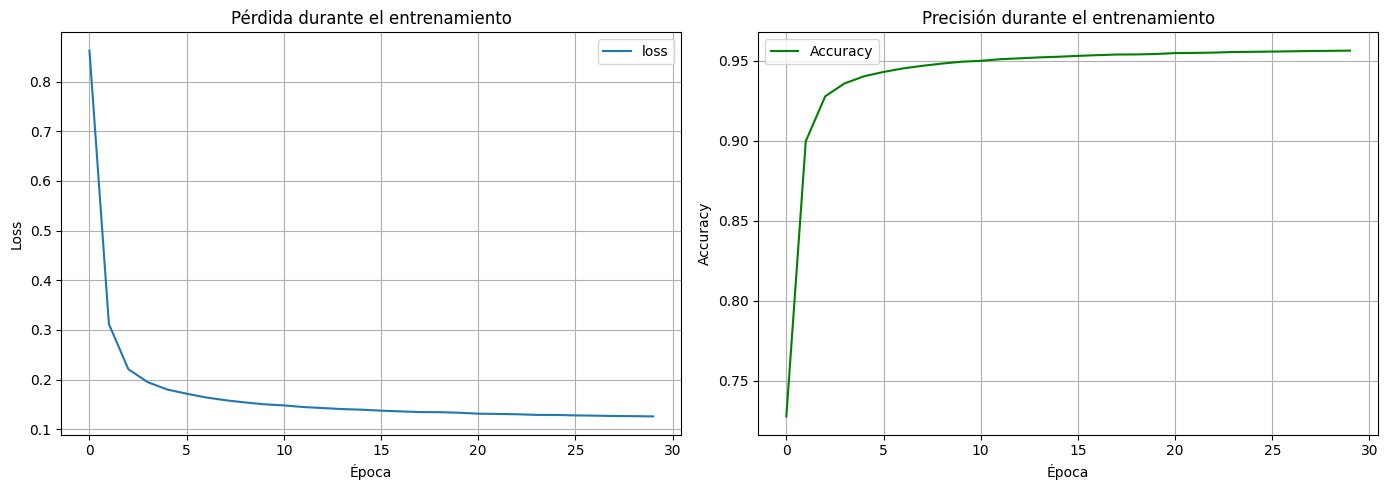

In [35]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pérdida
axes[0].plot(history.history['loss'], label='loss')
axes[0].set_title('Pérdida durante el entrenamiento')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# Precisión
axes[1].plot(history.history['accuracy'], label='Accuracy', color='green')
axes[1].set_title('Precisión durante el entrenamiento')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [38]:
def generar_text(model, inicio, longitud=100, temperatura=1.0):
  """Genera texto de forma autoregresiva."""
  generado = list(encode(inicio))

  for _ in range(longitud):
    input_seq = generado[-SEQ_LENGTH:]
    input_seq = np.array(input_seq)[np.newaxis, :]

    if len(input_seq[0]) < SEQ_LENGTH:
      pad_len = SEQ_LENGTH - len(input_seq[0])
      input_seq = np.pad(input_seq, ((0, 0), (pad_len, 0)))

    preds = model.predict(input_seq, verbose=0)[0, -1, :]
    preds = np.log(preds + 1e-10) / temperatura
    preds = np.exp(preds) / np.sum(np.exp(preds))

    next_idx = np.random.choice(len(preds), p=preds)
    generado.append(next_idx)

    if idx_to_char[next_idx] == '\n':
      break

  return decode(generado)

# Generar con diferentes temperaturas
print("=== Temperatura 0.5 ===")
print(generar_text(model, "el gobierno ", temperatura=0.5))

print("=== Temperatura 1.0 ===")
print(generar_text(model, "el gobierno ", temperatura=1.0))

print("=== Temperatura 1.5 ===")
print(generar_text(model, "el gobierno ", temperatura=1.5))

inicios = [
  "el gobierno ",
  "la economia ",
  "el presidente ",
  "argentina ",
  "se espera "
]

for inicio in inicios:
  print(f"Inicio: {inicio}")
  print(f"  -> {generar_text(model, inicio, temperatura=0.8)}")
  print()

=== Temperatura 0.5 ===
el gobierno conscientes y medioamientos adaptados a la genetica individual

=== Temperatura 1.0 ===
el gobierno conscientes y adoptan modelos de trabajo colaboradores o competidores

=== Temperatura 1.5 ===
el gobierno conscientes y medioas con inteligencia emocional en un mundo agitado

Inicio: el gobierno 
  -> el gobierno con conciencia con ar


Inicio: la economia 
  -> la economia contorando con conciencia concia enfermedades antes de que aparezcan


Inicio: el presidente 
  -> el presidente a cciudades mas verdes y acciones y mas alla


Inicio: argentina 
  -> argentina como euprometidas con cibernetica para una navegacion segura en linea


Inicio: se espera 
  -> se espera acionantes modas para un mundo digital


